In [1]:
import sys
import os
# sys.path.append('../')
# sys.path.append('../modules/')
# sys.path.append('../util/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import random
from SFM_Finetune import models_Segmentation, models_Regression
from modules.modeling.deeplab import *
from modules.modeling.Unet_models import *
from util.metrics import *

## data visualization

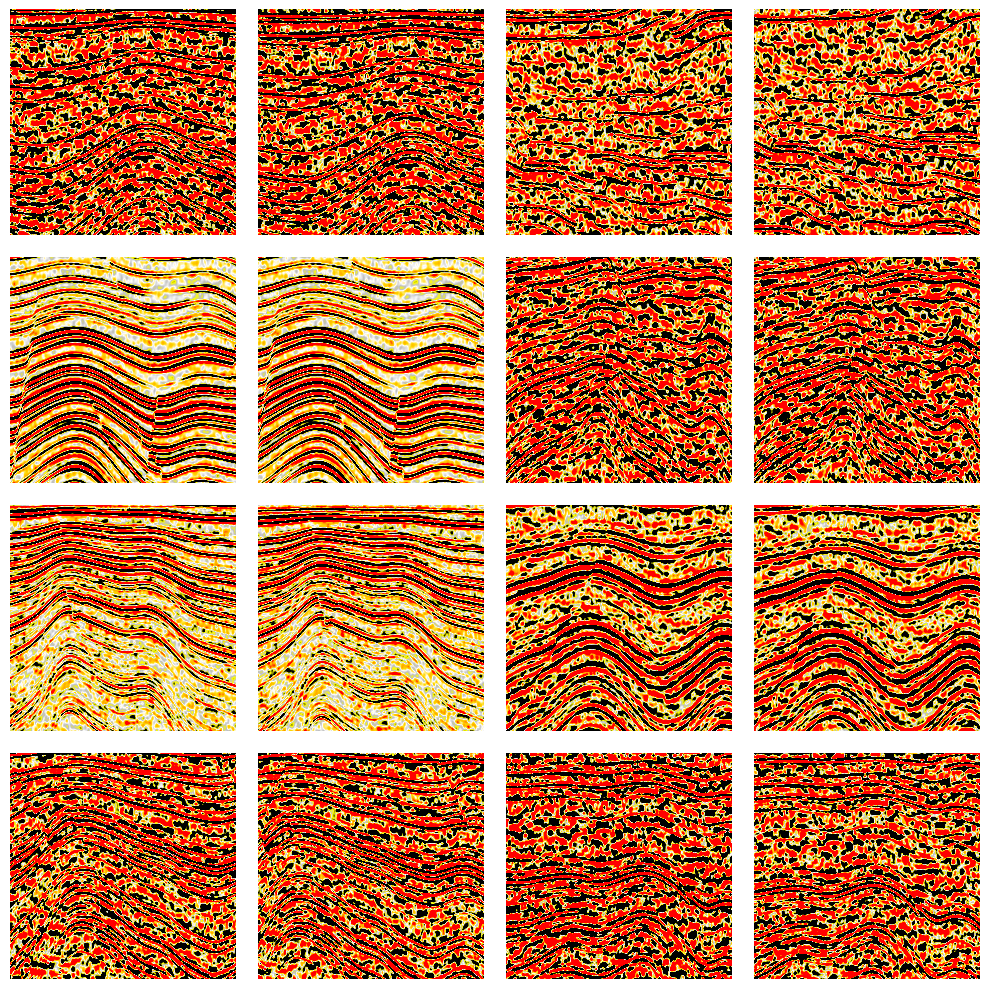

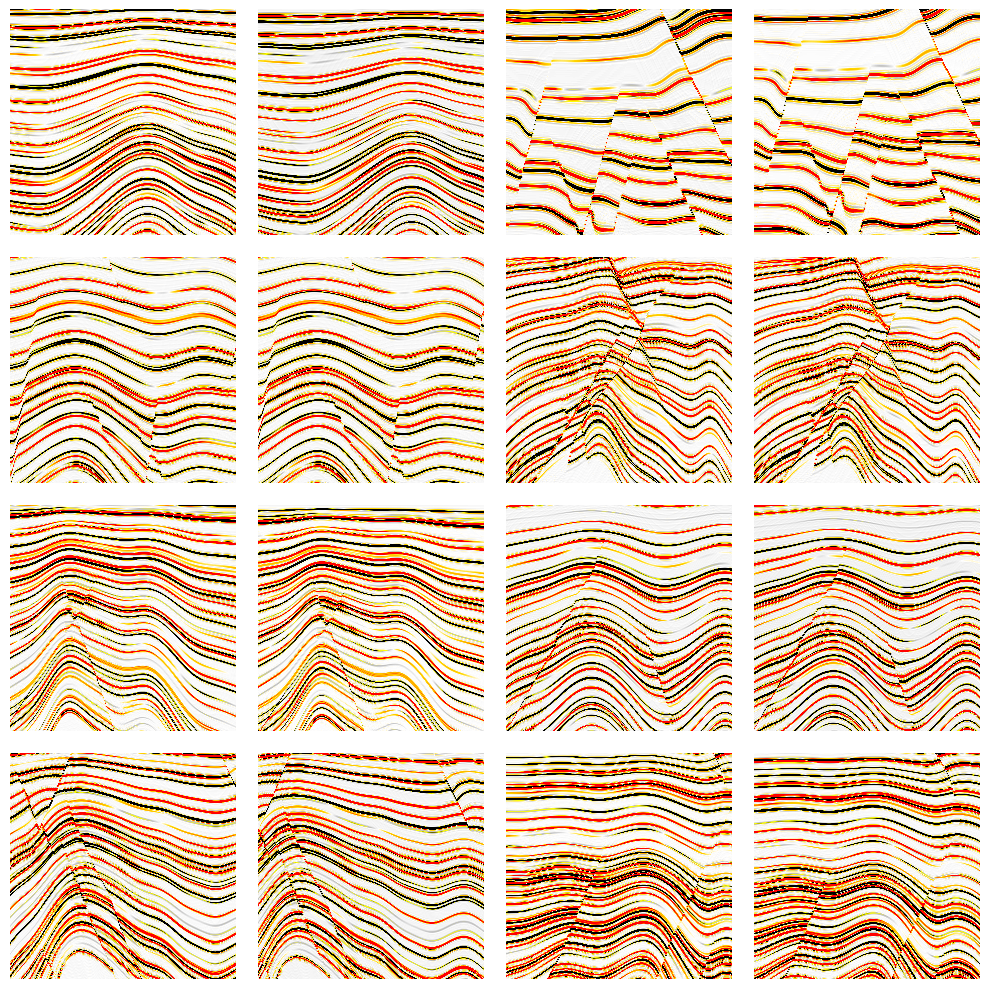

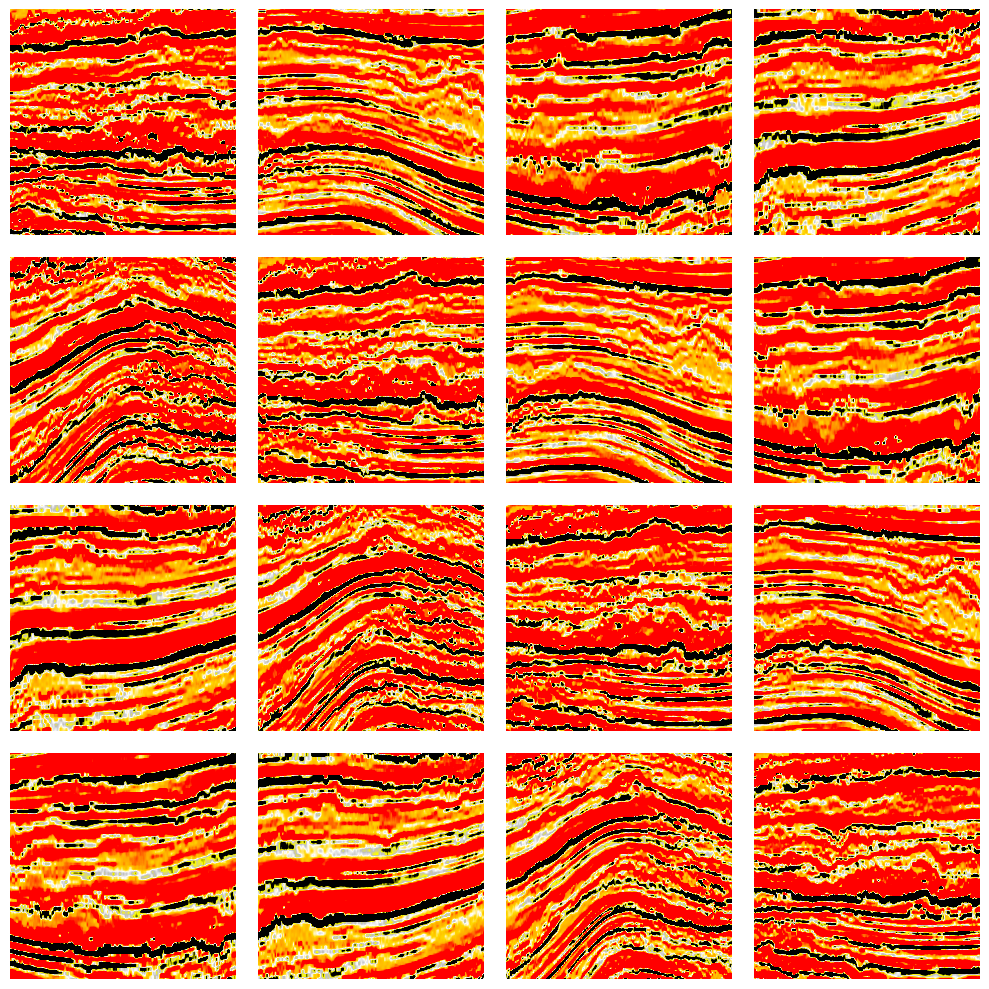

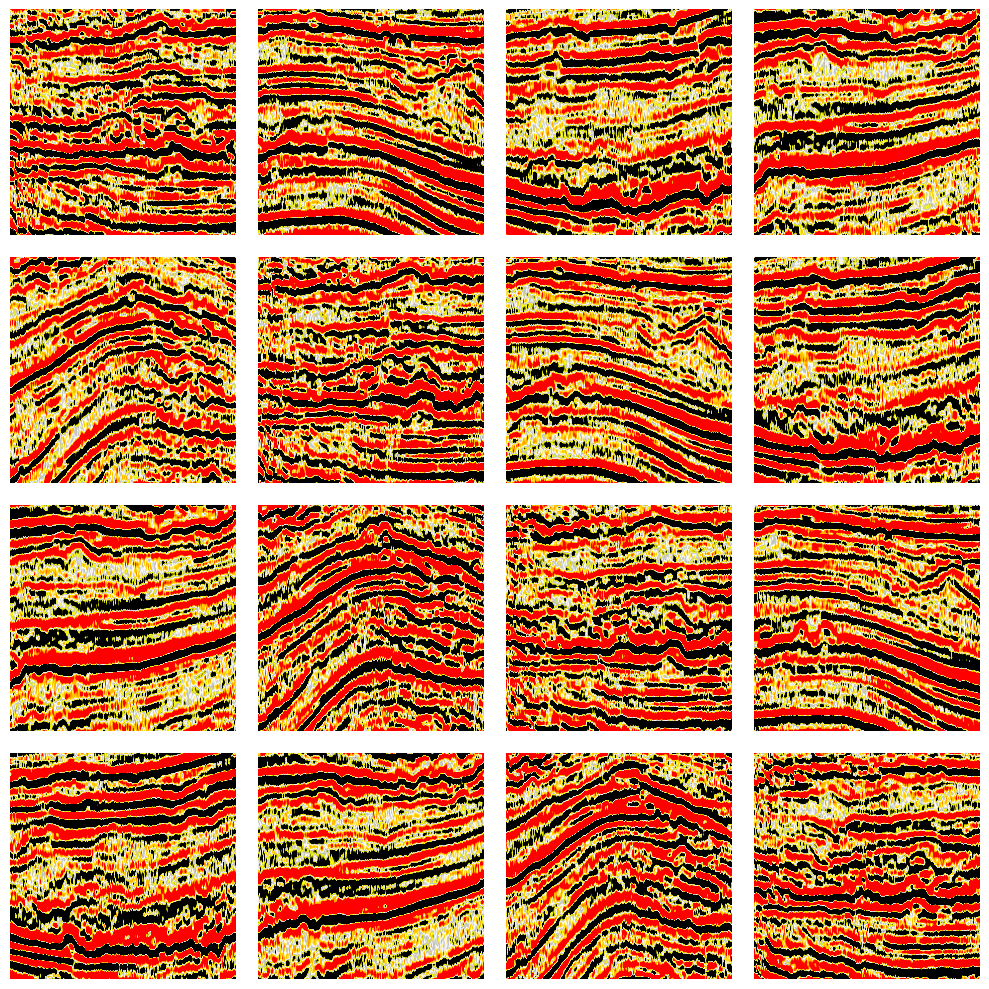

In [3]:
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)


data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'seismic/'
label_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'label/'
SEAMreflect = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'SEAMreflect/'
SEAMseismic = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'SEAMseismic/'

data_files =  [str(f)+'.dat' for f in range(100,117)]
# selected_files = random.sample(data_files, 16) # Random Select files to show
selected_files = data_files
for use_path in [data_path, label_path, SEAMreflect, SEAMseismic]:
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
    for i, ax in enumerate(axes.flatten()):
        with open(os.path.join(use_path, selected_files[i]), 'rb') as f:
            data = np.fromfile(f, dtype=np.single)
            img_size = int(np.sqrt(data.size))
            data = data.reshape((img_size, img_size))
            ax.imshow(data, cmap=cmap,vmin=np.min(data)/10,vmax=-np.min(data)/10)
            ax.axis('off')
    # 显示整个图像
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()

       11.18891,        -8.35060,         0.00631,         1.63129, 
        8.61030,       -11.40010,         0.00000,         1.00000, 
        0.01502,        -0.01335,         0.00103,         0.00258, 
        3.64975,        -4.37710,        -0.00332,         0.79026, 


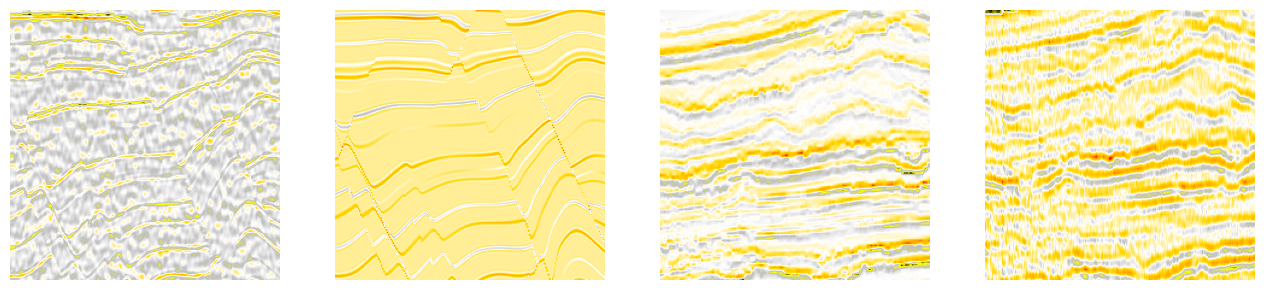

In [35]:
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)

data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'seismic/'
label_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'label/'
SEAMreflect = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'SEAMreflect/'
SEAMseismic = '/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'SEAMseismic/'

# show_idx = np.random.randint(0, 1999)
show_idx = 0
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(13, 3))
for use_path, axi in zip([data_path, label_path, SEAMreflect, SEAMseismic], axes.flatten()):
    with open(os.path.join(use_path, str(show_idx)+'.dat'), 'rb') as f:
        data = np.fromfile(f, dtype=np.single)
        img_size = int(np.sqrt(data.size))
        data = data.reshape((img_size, img_size))
        print('%15.5f, %15.5f, %15.5f, %15.5f, ' % (data.max(), data.min(), data.mean(), data.std(), ))
        # mean = data.mean()
        # var = data.var()
        # data = (data - mean) / (var + 1.e-6)**.5
        # print('%15.5f, %15.5f, %15.5f, %15.5f, ' % (data.max(), data.min(), data.mean(), data.std(), ))
        # axi.imshow(data, cmap=cmap,vmin=np.min(data)/2, vmax=-np.min(data)/2)
        axi.imshow(data, cmap=cmap)
        axi.axis('off')
# 显示整个图像
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## load Model

In [36]:
def prepare_model(chkpt_dir, arch='vit_base_patch16', img_size=224):
    # 检查是否有可用的GPU
    if torch.cuda.is_available():
        # 获取GPU的数量
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs available: {num_gpus}")
    
        # 遍历每个GPU并打印详细信息
        for i in range(num_gpus):
            print(f"GPU {i} details:")
            # 获取GPU的名称
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  Name: {gpu_name}")
            # 获取GPU的计算能力
            gpu_capability = torch.cuda.get_device_capability(i)
            print(f"  Compute Capability: {gpu_capability[0]}.{gpu_capability[1]}")
            # 获取GPU的显存总量
            gpu_memory = torch.cuda.get_device_properties(i).total_memory
            print(f"  Total Memory: {gpu_memory / 1e9:.2f} GB")
            # 获取GPU的当前占用显存
            gpu_current_memory = torch.cuda.memory_allocated(i)
            print(f"  Current Memory Allocated: {gpu_current_memory / 1e9:.2f} GB")
            # 获取GPU的当前缓存显存
            gpu_cached_memory = torch.cuda.memory_reserved(i)
            print(f"  Current Memory Cached: {gpu_cached_memory / 1e9:.2f} GB")

        # 选择内存使用量最小的显卡
        num_gpus = torch.cuda.device_count()
        min_memory_usage = float('inf')
        selected_gpu = None    
        for i in range(num_gpus):
            memory_allocated = torch.cuda.memory_allocated(i)
            if memory_allocated < min_memory_usage:
                min_memory_usage = memory_allocated
                selected_gpu = i
        print("GPU %d is selected." % selected_gpu)
        device = torch.device(f'cuda:{selected_gpu}')
    else:
        print("No GPU available.")
        device = torch.device('cpu')

    model = getattr(models_Regression, arch)(img_size=img_size,
                                             num_classes=1,
                                             drop_path_rate=0.1,
                                             in_chans=1,
                                             Interpolation=False)                                            
    checkpoint = torch.load(chkpt_dir, map_location=device)
#     interpolate_pos_embed(model, checkpoint['model'])
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    model.to(device)
    return model 

#load model
chkpt_dir = '/home/zhangji/LLM/Geophysics/output_dir/train_base_A100/finetune_checkpoint-1599/Reflection/checkpoint-99.pth' 
model_SFM = prepare_model(chkpt_dir, 'vit_base_patch16', img_size=224)

Number of GPUs available: 2
GPU 0 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 1 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 0 is selected.
<All keys matched successfully>


In [37]:
print(model_SFM)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

torch.Size([224, 224])


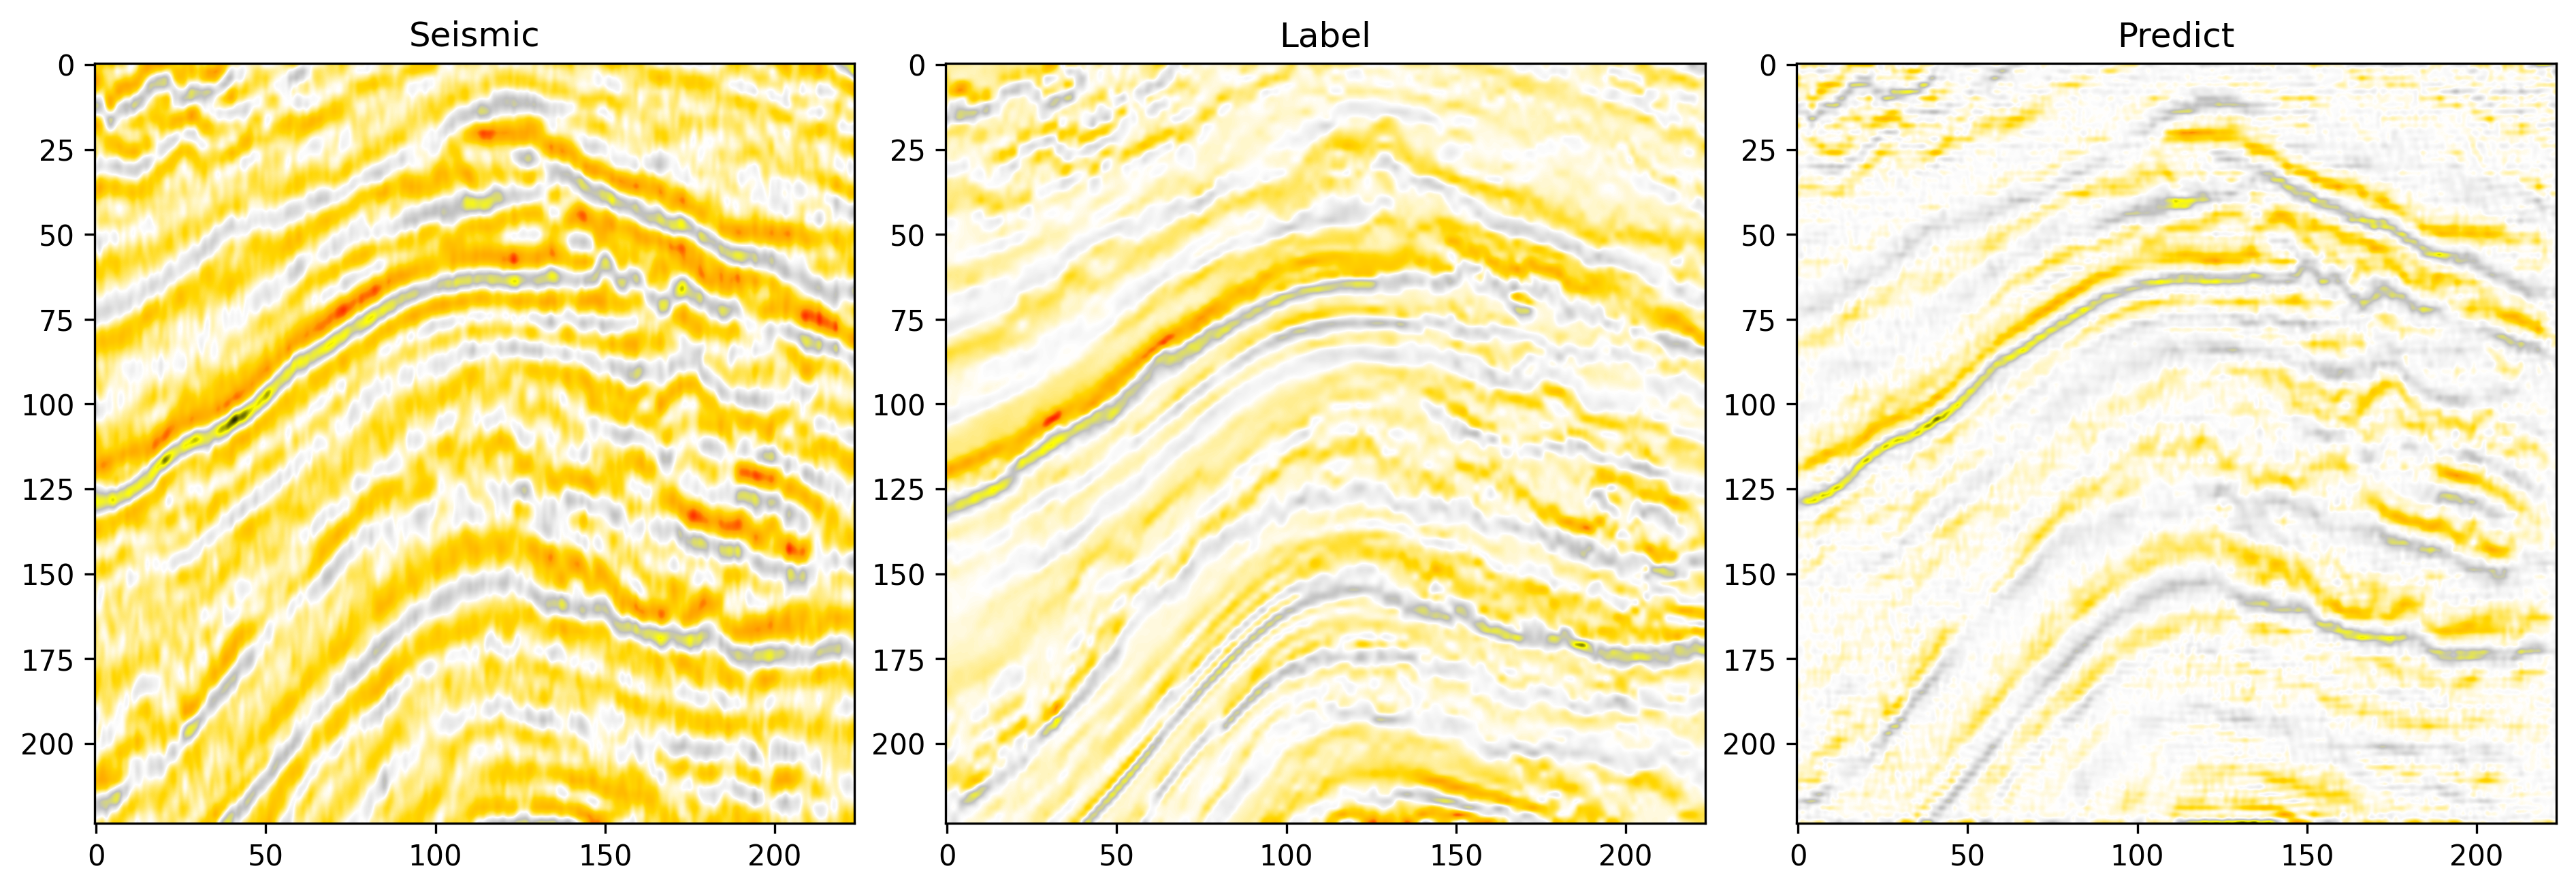

In [49]:
def run_one_image(img, model,l):
    color_list = ['#F19E9C','#EB5C56','#43972B','#FEE76B','#F3B677','#0082F4'] #seam
    cmapl = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    color_list = ['black','yellow','silver','white','gold','orange','red']
    cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    device = next(model.parameters()).device
    model.eval()
    
    x = torch.tensor(img).to(device)
    x = x.unsqueeze(0)
    x = x.unsqueeze(0)
    pred = model(x)
    pred = pred.detach().cpu()
    pred = pred.squeeze(0).reshape(img.shape)
    # pred = pred.squeeze(0)
    print(pred.shape)
    
    figsize = np.array([25, 10]) * 0.5
    dpi = 300
    # vmin, vmax = x.min()/5, x.max()/5
    vmin, vmax = None, None
    fig, axs = plt.subplots(1, 3, figsize=figsize, dpi=dpi, constrained_layout=True)
    axi = axs[0]
    axi.imshow(img , cmap=cmap, interpolation='bicubic', vmin=vmin, vmax=vmax)
    axi.set_title("Seismic")
    axi = axs[1]
    axi.imshow(l   , cmap=cmap, interpolation='bicubic', vmin=vmin, vmax=vmax)
    axi.set_title("Label")
    axi = axs[2]
    axi.imshow(pred, cmap=cmap, interpolation='bicubic', vmin=vmin, vmax=vmax)
    axi.set_title("Predict")
    
# data_list = ['/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'seismic/'+ str(f)+'.dat' for f in range(2200)]
# label_list = [f.replace('/seismic/', '/label/') for f in data_list]

data_list = ['/home/zhangji/sdb1_data/Geophysics_data/Data/Inversion/' +'SEAMseismic/'+ str(f)+'.dat' for f in range(2200)]
label_list = [f.replace('/SEAMseismic/', '/SEAMreflect/') for f in data_list]

# dnum = np.random.randint(100, 117) # we use 0-99 as the training dataset and 100-116 as the validation dataset
# print(dnum)
dnum = 114
d = np.fromfile(data_list[dnum], np.float32).reshape((224, 224))
l = np.fromfile(label_list[dnum], np.float32).reshape([224, 224])
run_one_image(d, model_SFM, l)